## QLoRA-based SFT of Llama 3.2 3B Intruct using Unsloth
> To judge Indian constitutional case arguments in Themis, an online moot court simulator

In [1]:
!pip install -q \
unsloth \
"transformers==4.51.3" \
"trl==0.15.2" \
accelerate \
bitsandbytes \
datasets \
huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Prefer extending a segment over allocating new ones <br>
Reduce chances of OOM caused by fragmentation 

In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
hf_token = secrets.get_secret('HF_TOKEN')
login(token=hf_token)

In [4]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="https://huggingface.co/datasets/snowsadh/themis-judge-sft/resolve/main/dataset.json",
    split="train"
)

print(f"Dataset Size: {len(dataset)}")
#print(dataset[0])

dataset.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset Size: 504


### Loading Quantized Model with Unsloth

In [5]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LEN=2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name='unsloth/Llama-3.2-3B-Instruct',
    max_seq_length=MAX_SEQ_LEN,
    dtype=None,           # auto-detect
    load_in_4bit=True,    # quantize
    device_map={'': 0},
)

EOS_TOKEN = tokenizer.eos_token
print(f'EOS token: {EOS_TOKEN}')
print(f'Model loaded. Vocab size: {tokenizer.vocab_size}')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-05-28 18:24:41.676691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779992682.090440      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779992682.202403      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779992683.224565      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779992683.224626      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779992683.224628      24 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.10.8: Fast Llama patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

EOS token: <|eot_id|>
Model loaded. Vocab size: 128000


### Adding LoRA Adapters

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj'
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=69,
)

print('LoRA adapters added.')
model.print_trainable_parameters()

FastLanguageModel.for_training(model)
print('Model set to training mode.')

Unsloth 2025.10.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


LoRA adapters added.
trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511
Model set to training mode.


### Formatting Dataset

In [7]:
import json

prompt_template = """### Case Summary:
{case_summary}

### Legal Issue:
{legal_issue}

### Relevant Laws:
{relevant_laws}

### Side:
{side}

### Opposing Counsel Argument:
{opposing_last_argument}

### Previous Judge Response:
{judge_last_response}

### CurrentArgument:
{current_argument}

### Judge Response:
{output}{eos_token}"""


def format_sample(sample, eos_token):
    inp = sample['input']
    prompt = prompt_template.format(
        case_summary=inp['case_summary'],
        legal_issue=inp['legal_issue'],
        relevant_laws=inp['relevant_laws'] if isinstance(inp['relevant_laws'], str) else ', '.join(inp['relevant_laws']),    # if in list format, convert into string
        side=inp['side'].upper(),
        opposing_last_argument=inp.get('opposing_last_argument', 'None'),
        judge_last_response=inp.get('judge_last_response', 'None'),
        current_argument=inp['current_argument'],
        output=json.dumps(sample['output'], ensure_ascii=False),    # JSON string output
        eos_token=eos_token
    ) 
    return {'text': prompt}


print('Formatted Sample\n')
sample = format_sample(dataset[0], eos_token=EOS_TOKEN)
print(sample['text'])

Formatted Sample

### Case Summary:
This case originated from letters to the Chief Justice of India highlighting deaths in police custody. The court treated these letters as writ petitions under public interest litigation. The petitioners sought accountability for custodial deaths and compensation for victims. The respondents, various state governments, initially denied any wrongdoing. The Supreme Court, concerned about increasing custodial violence, formulated guidelines to minimize such incidents and ensure compensation for victims' families.

### Legal Issue:
Whether custodial violence, including torture and death in police lock-ups, violates the fundamental rights guaranteed under Articles 21 and 22 of the Constitution of India, and if so, what measures are necessary to protect these rights and provide redressal to victims.

### Relevant Laws:
Article 21 Constitution of India, Article 22 Constitution of India, Article 20(3) Constitution of India, Article 5 Universal Declaration of 

In [8]:
formatted = dataset.map(
    # for each row in dataset
    lambda ex: format_sample(ex, EOS_TOKEN),
    remove_columns=dataset.column_names
    # only keep the new column 'text'
)

split = formatted.train_test_split(test_size=0.1, seed=69)
train_dataset = split['train']
eval_dataset = split['test']

print(f'Train: {len(train_dataset)} examples')
print(f'Eval: {len(eval_dataset)} examples')
print(f'\nSample prompt length: {len(train_dataset[0]["text"])} chars')

Map:   0%|          | 0/504 [00:00<?, ? examples/s]

Train: 453 examples
Eval: 51 examples

Sample prompt length: 2837 chars


### Training the Model

In [9]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field='text',
    max_seq_length=MAX_SEQ_LEN,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=3,
        warmup_steps=10,
        learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        output_dir='outputs',
        optim='adamw_8bit',
        weight_decay=0.01,
        lr_scheduler_type='linear',
        seed=69,
        report_to='none',
    )
)
'''

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    dataset_text_field='text',
    max_seq_length=MAX_SEQ_LEN,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=4,
        gradient_accumulation_steps=8,
        num_train_epochs=3,
        learning_rate=2e-4,
        logging_steps=10,
        save_strategy='epoch',
        output_dir='outputs',
        optim='adamw_8bit',
        report_to='none',
    )
)
'''

print('Trainer configured. Starting training...')
trainer_stats = trainer.train()
print(f'Training complete. Runtime: {trainer_stats.metrics["train_runtime"]:.1f}s')

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/453 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/51 [00:00<?, ? examples/s]

Trainer configured. Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 453 | Num Epochs = 3 | Total steps = 84
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
0,1.462000,1.243311
1,1.049700,1.013760
2,0.854400,0.898572


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Training complete. Runtime: 1376.4s


### Checking loss curve

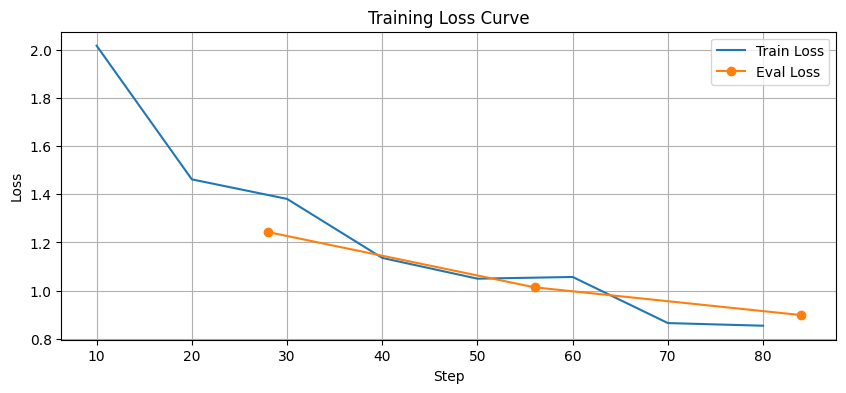

Final train loss: 0.8544
Final eval loss: 0.8986


In [10]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [x['step'] for x in log_history if 'loss' in x]
train_loss = [x['loss'] for x in log_history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_loss, label='Train Loss')
plt.plot(eval_steps, eval_loss, label='Eval Loss', marker='o')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f'Final train loss: {train_loss[-1]:.4f}')
if len(eval_loss) > 0:
    print(f'Final eval loss: {eval_loss[-1]:.4f}')

### Evaluating

In [11]:
FastLanguageModel.for_inference(model)

test_example = eval_dataset[0]['text']
prompt_only = test_example.split('### Judge Response:')[0] + '### Judge Response:\n'

inputs = tokenizer(prompt_only, return_tensors='pt').to('cuda')

outputs = model.generate(
    **inputs,
    max_new_tokens=300,
    temperature=0.3,    # low T for stable evaluation
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)

generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
print('Model output:')
print(generated)
print('\nExpected output:')
print(test_example.split('### Judge Response:')[1])

Model output:
{"delta_scores": {"legal_application": 0, "issue_relevance": 3, "argument_flow": 2, "bench_handling": 1}, "judge_response": "Counsel, you rely on Maneka Gandhi and Olga Tellis — how do those cases specifically address the nature of an inquiry into a witness's credibility, as opposed to a trial or review of a final order?", "speaker_switch": false, "judge_notes": "Cited Maneka Gandhi and Olga Tellis but didn't apply them to the specific inquiry context — needs to address whether those cases are directly applicable."}

Expected output:

{"delta_scores": {"legal_application": -1, "issue_relevance": 3, "argument_flow": 2, "bench_handling": 2}, "judge_response": "The bench will now hear the petitioner on whether the inquiry met the standards of natural justice.", "speaker_switch": true, "judge_notes": "Respondent cited broad cases but didn't grapple with the specific inquiry flaws — avoided the core tension between Article 142 and natural justice, gave a generic answer."}<|eot

In [12]:
trainer.save_model("final_checkpoint")

### Yippeee!!!

Saving LoRA Adapters

In [13]:
REPO_NAME = 'snowsadh/themis-judge-lora'

'''
model.push_to_hub(REPO_NAME, token=hf_token)
tokenizer.push_to_hub(REPO_NAME, token=hf_token)
'''

print(f'LoRA adapter saved to: https://huggingface.co/{REPO_NAME}')

LoRA adapter saved to: https://huggingface.co/snowsadh/themis-judge-lora


Saving Ultimate Merged Model

In [14]:
MERGED_REPO = 'snowsadh/themis-judge-3b'

'''
model.push_to_hub_merged(
    MERGED_REPO,
    tokenizer,
    save_method='merged_16bit',
    token=hf_token
)
'''

print(f'Merged model saved to: https://huggingface.co/{MERGED_REPO}')

Merged model saved to: https://huggingface.co/snowsadh/themis-judge-3b
